#### Decodificando la Ley: Clasificación Inteligente y Búsqueda Semántica de Jurisprudencia Argentina

##### Descarga del dataset completo

Instalamos primero las librerías que necesitaremos y luego las importamos

In [ ]:
# %pip install huggingface_hub datasets pandas

In [ ]:
# Importamos librerías
from huggingface_hub import snapshot_download
import pandas as pd
import os

# # Variables de configuración
# DATASET_PATH = "datos/full-dataset"
# RANDOM_SEED = 42

DATASET_PATH = "gitrepo\\datos\\dataset_sample.jsonl.gz"


Descargamos el dataset completo (~2.5GB)

In [ ]:
# # Importamos librerías
# from huggingface_hub import snapshot_download, login
# import pandas as pd
# import os

# # Autenticación
# HF_TOKEN = ""  # Reemplaza con tu token de Hugging Face
# login(token=HF_TOKEN)

# # Variables de configuración
# DATASET_PATH = "datos/full-dataset"
# RANDOM_SEED = 42

# # Si el dataset ya existe localmente, no lo descargamos de nuevo
# if os.path.isdir(DATASET_PATH):
#     print("El dataset ya ha sido descargado previamente.")
# else:
#     print("Descargando el dataset...")

#     snapshot_download(
#         repo_id="marianbasti/jurisprudencia-Argentina-SAIJ",
#         repo_type="dataset",
#         local_dir=DATASET_PATH,
#         token=HF_TOKEN
#     )

#     print("Descarga finalizada.")

##### Lectura de los datasets

Dataset completo

In [ ]:
# df = pd.read_json(
#     os.path.join(DATASET_PATH, "dataset.jsonl"),
#     lines=True
# )

Dataset de ejemplo (muestra del 1% del dataset completo)

In [ ]:
from huggingface_hub import snapshot_download
import pandas as pd
import os
from pathlib import Path

pd.set_option("display.max_rows", None)      # muestra todas las filas
pd.set_option("display.max_columns", None)   # opcional: todas las columnas
pd.set_option("display.max_colwidth", None)  #

DATASET_PATH = Path("datos") / "dataset_sample.jsonl.gz"

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en {DATASET_PATH.resolve()}. "
        "Asegurate de que el archivo exista en la carpeta `datos`."
    )

df_sample = pd.read_json(
    DATASET_PATH,
    lines=True,
    compression="gzip"
)

# df_sample = pd.read_json(
#     "dataset_sample.jsonl.gz",
#     lines=True,
#     compression="gzip"
# )

In [ ]:
df_sample.head()

In [ ]:


df_sample.head()

#analisis de valores nuilos por columna 
n_filas = len(df_sample)

df_nulos = pd.DataFrame({
    "columna": df_sample.columns,
    "nulos": df_sample.isnull().sum().values,
    "no_nulos": df_sample.notna().sum().values,
    "pct_nulos": df_sample.isnull().sum().values / n_filas * 100,
    "pct_completos": df_sample.notna().sum().values / n_filas * 100,
}).assign(
    tiene_nulos=lambda d: d["nulos"] > 0
).sort_values("pct_nulos", ascending=False).reset_index(drop=True)

# Solo columnas con al menos un valor nulo
df_nulos[df_nulos["tiene_nulos"]]

#dataset sin columnas vacias 
def es_vacio(serie: pd.Series) -> pd.Series:
    """Marca valores nulos (NaN/None) y strings vacíos como vacíos."""
    vacios = serie.isna()
    if serie.dtype == object:
        vacios = vacios | (serie == "")
    return vacios


UMBRAL_VACIOS = 99.97  # redondeado a 2 decimales (ej. 99.965706% -> 99.97%)

pct_vacios = df_sample.apply(lambda col: es_vacio(col).mean() * 100)
columnas_removidas = pct_vacios[pct_vacios.round(2) >= UMBRAL_VACIOS].index.tolist()

df_columnas_removidas = (
    pct_vacios[columnas_removidas]
    .rename("pct_vacios")
    .reset_index()
    .rename(columns={"index": "columna"})
    .sort_values("pct_vacios", ascending=False)
    .reset_index(drop=True)
)

df_sample_limpio = df_sample.drop(columns=columnas_removidas)

print(f"Umbral aplicado: >= {UMBRAL_VACIOS}% vacíos (redondeado)")
print(f"Columnas removidas ({len(columnas_removidas)}):")
print(columnas_removidas)
print(f"\nShape original: {df_sample.shape}")
print(f"Shape limpio:   {df_sample_limpio.shape}")

df_columnas_removidas


df_sample_limpio.columns.to_list()


n_filas = len(df_sample_limpio)

df_nulos = pd.DataFrame({
    "columna": df_sample_limpio.columns,
    "nulos": df_sample_limpio.isnull().sum().values,
    "no_nulos": df_sample_limpio.notna().sum().values,
    "pct_nulos": df_sample_limpio.isnull().sum().values / n_filas * 100,
    "pct_completos": df_sample_limpio.notna().sum().values / n_filas * 100,
}).assign(
    tiene_nulos=lambda d: d["nulos"] > 0
).sort_values("pct_nulos", ascending=False).reset_index(drop=True)

# Solo columnas con al menos un valor nulo
df_nulos[df_nulos["tiene_nulos"]]


total_filas = len(df_sample_limpio)
pais_con_valor = df_sample_limpio["pais"].notna().sum()
pais_nulos = df_sample_limpio["pais"].isna().sum()

print(f"Total filas:        {total_filas}")
print(f"Con país informado: {pais_con_valor} ({pais_con_valor / total_filas * 100:.2f}%)")
print(f"Nulos (sin país):   {pais_nulos} ({pais_nulos / total_filas * 100:.2f}%)")
print(f"\nVerificación: value_counts().sum() = {df_sample_limpio['pais'].value_counts().sum()}")

df_sample_limpio["pais"].value_counts(dropna=False)


total_filas = len(df_sample_limpio)
provincia_con_valor = df_sample_limpio["provincia"].notna().sum()
provincia_nulos = df_sample_limpio["provincia"].isna().sum()

print(f"Total filas:            {total_filas}")
print(f"Con provincia informada: {provincia_con_valor} ({provincia_con_valor / total_filas * 100:.2f}%)")
print(f"Nulos (sin provincia):   {provincia_nulos} ({provincia_nulos / total_filas * 100:.2f}%)")
print(f"\nVerificación: value_counts().sum() = {df_sample_limpio['provincia'].value_counts().sum()}")

df_sample_limpio["provincia"].value_counts(dropna=False)


df_sample_limpio.pais.value_counts()


def es_vacio(serie: pd.Series) -> pd.Series:
    vacios = serie.isna()
    if serie.dtype == object:
        vacios = vacios | (serie == "")
    return vacios

sin_provincia = df_sample_limpio[df_sample_limpio["provincia"].isna()]
n = len(sin_provincia)

columnas_con_datos = []
for col in sin_provincia.columns:
    no_vacios = (~es_vacio(sin_provincia[col])).sum()
    if no_vacios > 0:
        columnas_con_datos.append({
            "columna": col,
            "no_vacios": no_vacios,
            "pct_filas": no_vacios / n * 100,
        })

df_cols_sin_provincia = (
    pd.DataFrame(columnas_con_datos)
    .sort_values("no_vacios", ascending=False)
    .reset_index(drop=True)
)

df_cols_sin_provincia


sin_provincia.head()



sin_provincia = es_vacio(df_sample_limpio["provincia"])
sin_fecha = es_vacio(df_sample_limpio["fecha"])
sin_fecha_alta = es_vacio(df_sample_limpio["fecha-alta"])

dropeables = sin_provincia & sin_fecha_alta
resto = sin_provincia & ~sin_fecha_alta

print(f"Dropeables: {dropeables.sum()}")
print(f"Resto sin provincia: {resto.sum()}")
print(f"Quedarían en total: {len(df_sample_limpio) - dropeables.sum()}")

df_sample_limpio[dropeables].shape
df_sample_limpio[resto][["provincia", "fecha", "fecha-alta", "pais", "materia", "texto"]]


df_filtrado = df_sample_limpio[~dropeables]


df_filtrado.shape


total_filas = len(df_filtrado)
provincia_con_valor = df_filtrado["provincia"].notna().sum()
provincia_nulos = df_filtrado["provincia"].isna().sum()

print(f"Total filas:            {total_filas}")
print(f"Con provincia informada: {provincia_con_valor} ({provincia_con_valor / total_filas * 100:.2f}%)")
print(f"Nulos (sin provincia):   {provincia_nulos} ({provincia_nulos / total_filas * 100:.2f}%)")
print(f"\nVerificación: value_counts().sum() = {df_filtrado['provincia'].value_counts().sum()}")

df_filtrado["provincia"].value_counts(dropna=False)


provincias_extranjeras = [
    "San José de Costa Rica",
    "Ginebra",
    "Bajo Rin",
    "Madrid",
]

df_filtrado[df_filtrado["provincia"].isin(provincias_extranjeras)][
    ["provincia", "pais", "jurisdiccion", "materia", "caratula"]
]


provincias_extranjeras = [
    "San José de Costa Rica",
    "Ginebra",
    "Bajo Rin",
    "Madrid",
]

df_filtrado_arg = df_filtrado[~df_filtrado["provincia"].isin(provincias_extranjeras)]

total_filas = len(df_filtrado_arg)
provincia_con_valor = df_filtrado_arg["provincia"].notna().sum()
provincia_nulos = df_filtrado_arg["provincia"].isna().sum()

print(f"Filas removidas (provincias extranjeras): {len(df_filtrado) - total_filas}")
print(f"Total filas:            {total_filas}")
print(f"Con provincia informada: {provincia_con_valor} ({provincia_con_valor / total_filas * 100:.2f}%)")
print(f"Nulos (sin provincia):   {provincia_nulos} ({provincia_nulos / total_filas * 100:.2f}%)")
print(f"\nVerificación: value_counts().sum() = {df_filtrado_arg['provincia'].value_counts().sum()}")

df_filtrado_arg["provincia"].value_counts(dropna=False)


import matplotlib.pyplot as plt

conteo_provincia = (
    df_filtrado_arg["provincia"]
    .fillna("Sin provincia")
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 10))
conteo_provincia.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Cantidad de registros por provincia")
ax.set_xlabel("Cantidad")
ax.set_ylabel("Provincia")
plt.tight_layout()
plt.show()

In [ ]:
# Analizamos la cantidad de palabras y el largo del texto en la columna "texto"

# Cantidad de palabras por registro
# Se reemplazan los valores nulos por cadenas vacías para evitar errores
palabras_texto = df_filtrado_arg["texto"].fillna("").str.split().str.len()

# Largo en caracteres por registro
largo_texto = df_filtrado_arg["texto"].fillna("").str.len()

# Agregamos estas columnas al DataFrame
df_filtrado_arg["n_palabras_texto"] = palabras_texto
df_filtrado_arg["longitud_texto"] = largo_texto

# Resumen estadístico
pd.DataFrame({
    "n_palabras_texto": palabras_texto,
    "longitud_texto": largo_texto
}).describe()

df_filtrado_arg.head(2)

In [ ]:
# ------------------------------------------------------------
# 1) Candidatas a variable objetivo
# ------------------------------------------------------------
candidatas = ["fuero", "tribunal", "materia", "jurisdiccion", "provincia", "pais"]

for col in candidatas:
    if col in df_sample_limpio.columns:
        s = df_sample_limpio[col]
        print(f"\n=== {col} ===")
        print("nulos:", s.isna().sum())
        print("cant_clases:", s.dropna().nunique())
        print(s.value_counts(dropna=False).head(15))

In [ ]:
# ------------------------------------------------------------
# 2) Resumen de calidad de cada candidata
# ------------------------------------------------------------
resumen = []

for col in candidatas:
    if col in df_sample_limpio.columns:
        s = df_sample_limpio[col].dropna()
        counts = s.value_counts()
        resumen.append({
            "columna": col,
            "nulos": df_sample_limpio[col].isna().sum(),
            "clases": counts.shape[0],
            "clase_mas_comun": counts.index[0] if not counts.empty else None,
            "freq_clase_mas_comun": int(counts.iloc[0]) if not counts.empty else None,
            "min_freq": int(counts.min()) if not counts.empty else None,
            "max_freq": int(counts.max()) if not counts.empty else None,
        })

pd.DataFrame(resumen).sort_values("clases", ascending=False)

In [ ]:
# ------------------------------------------------------------
# 3) Elegir una variable objetivo tentativa
# ------------------------------------------------------------
# Recomendación práctica: empezar por "fuero" si está completo y tiene suficiente cantidad
# de ejemplos por clase. Si no, probar "materia" o una versión agrupada.

target_cand = "materia" if "materia" in df_sample_limpio.columns else None

if target_cand is not None:
    s = df_sample_limpio[target_cand]
    print(f"\nTarget tentativa: {target_cand}")
    print(s.value_counts(dropna=False).head(20))

In [ ]:
import nltk
from nltk.corpus import stopwords

# 1. Descargar las stopwords (solo la primera vez)
nltk.download("stopwords")

In [87]:
# 2. Cargar la lista de stopwords en español
stop_words = set(stopwords.words("spanish"))
stop_words.add("uuid")
stop_words.add("art") # agrego esta solo para analizar la salida. 

In [88]:
# ------------------------------------------------------------
# 4) Ver si el texto aporta señal para esa variable
# ------------------------------------------------------------
# Para esto, podemos mirar palabras frecuentes por clase
# Primero, limpiamos y tokenizamos el texto
import re
from collections import Counter


def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    texto = re.sub(r"<[^>]+>", " ", texto)
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"[^a-záéíóúúñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


# Lista de stopwords en español de NLTK
# Se usa stop_words que se definió en la celda anterior

def tokenizar_y_limpiar(texto):
    limpio = limpiar_texto(texto)
    tokens = [tok for tok in limpio.split() if tok not in stop_words and len(tok) > 2]
    return tokens


# Elegimos el target solo si existe en el DataFrame
def analizar_texto_por_clase(target_col):
    if target_col is None or target_col not in df_sample_limpio.columns:
        print("No se encontró una columna válida para usar como target.")
        return

    df_texto = df_sample_limpio[[target_col, "texto"]].copy()
    df_texto["texto_limpio"] = df_texto["texto"].apply(limpiar_texto)
    df_texto["tokens"] = df_texto["texto_limpio"].apply(tokenizar_y_limpiar)

    for clase in df_texto[target_col].dropna().astype(str).unique()[:10]:
        subset = df_texto[df_texto[target_col].astype(str) == clase]["tokens"]
        tokens_flat = [tok for token_list in subset for tok in token_list]
        counter = Counter(tokens_flat)
        print(f"\n--- {clase} ---")
        print(counter.most_common(20))


analizar_texto_por_clase(target_cand)


--- CIVIL ---
[('debe', 177), ('civil', 159), ('ley', 133), ('código', 128), ('ser', 117), ('daño', 108), ('derecho', 107), ('caso', 99), ('puede', 96), ('pues', 91), ('hecho', 89), ('ello', 87), ('responsabilidad', 86), ('parte', 79), ('sino', 71), ('bien', 69), ('tal', 69), ('corresponde', 66), ('obligación', 65), ('resulta', 65)]

--- CIVIL - COMERCIAL ---
[('ley', 123), ('debe', 95), ('puede', 82), ('civil', 82), ('personal', 75), ('minoria', 73), ('opinion', 73), ('ser', 68), ('hecho', 61), ('derecho', 58), ('ello', 52), ('código', 52), ('sino', 50), ('sentencia', 49), ('sólo', 49), ('caso', 47), ('tal', 46), ('arts', 46), ('parte', 45), ('proceso', 44)]

--- LABORAL ---
[('ley', 298), ('trabajo', 212), ('trabajador', 155), ('debe', 130), ('empleador', 110), ('contrato', 106), ('caso', 93), ('laboral', 93), ('code', 92), ('puede', 91), ('artículo', 87), ('ser', 81), ('lct', 79), ('relación', 75), ('despido', 72), ('derecho', 71), ('ello', 69), ('indemnización', 68), ('parte', 60)

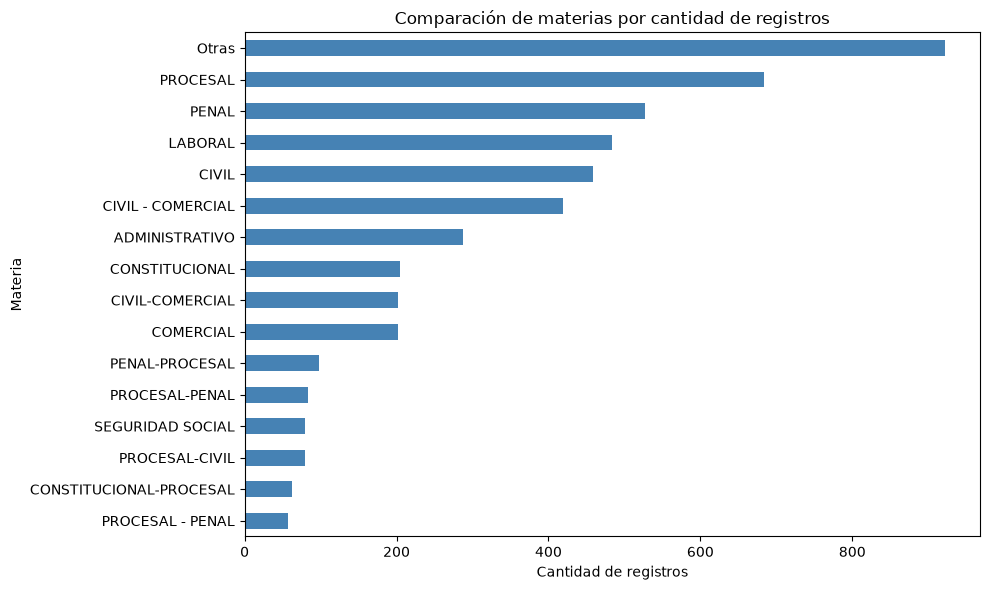

In [89]:
import matplotlib.pyplot as plt
import pandas as pd

# Gráfico para comparar categorías de materia
if "materia" in df_sample_limpio.columns:
    materias = (
        df_sample_limpio["materia"]
        .dropna()
        .astype(str)
        .str.strip()
        .replace("", pd.NA)
        .dropna()
        .value_counts()
    )

    if not materias.empty:
        top_n = 15
        if len(materias) > top_n:
            top = materias.head(top_n)
            otras = pd.Series({"Otras": int(materias.iloc[top_n:].sum())})
            datos = pd.concat([top, otras])
        else:
            datos = materias

        datos = datos.sort_values(ascending=True)

        fig, ax = plt.subplots(figsize=(10, 6))
        datos.plot(kind="barh", color="steelblue", ax=ax)
        ax.set_title("Comparación de materias por cantidad de registros")
        ax.set_xlabel("Cantidad de registros")
        ax.set_ylabel("Materia")
        plt.tight_layout()
        plt.show()
    else:
        print("No hay valores de materia para graficar.")
else:
    print("La columna 'materia' no existe en el DataFrame.")


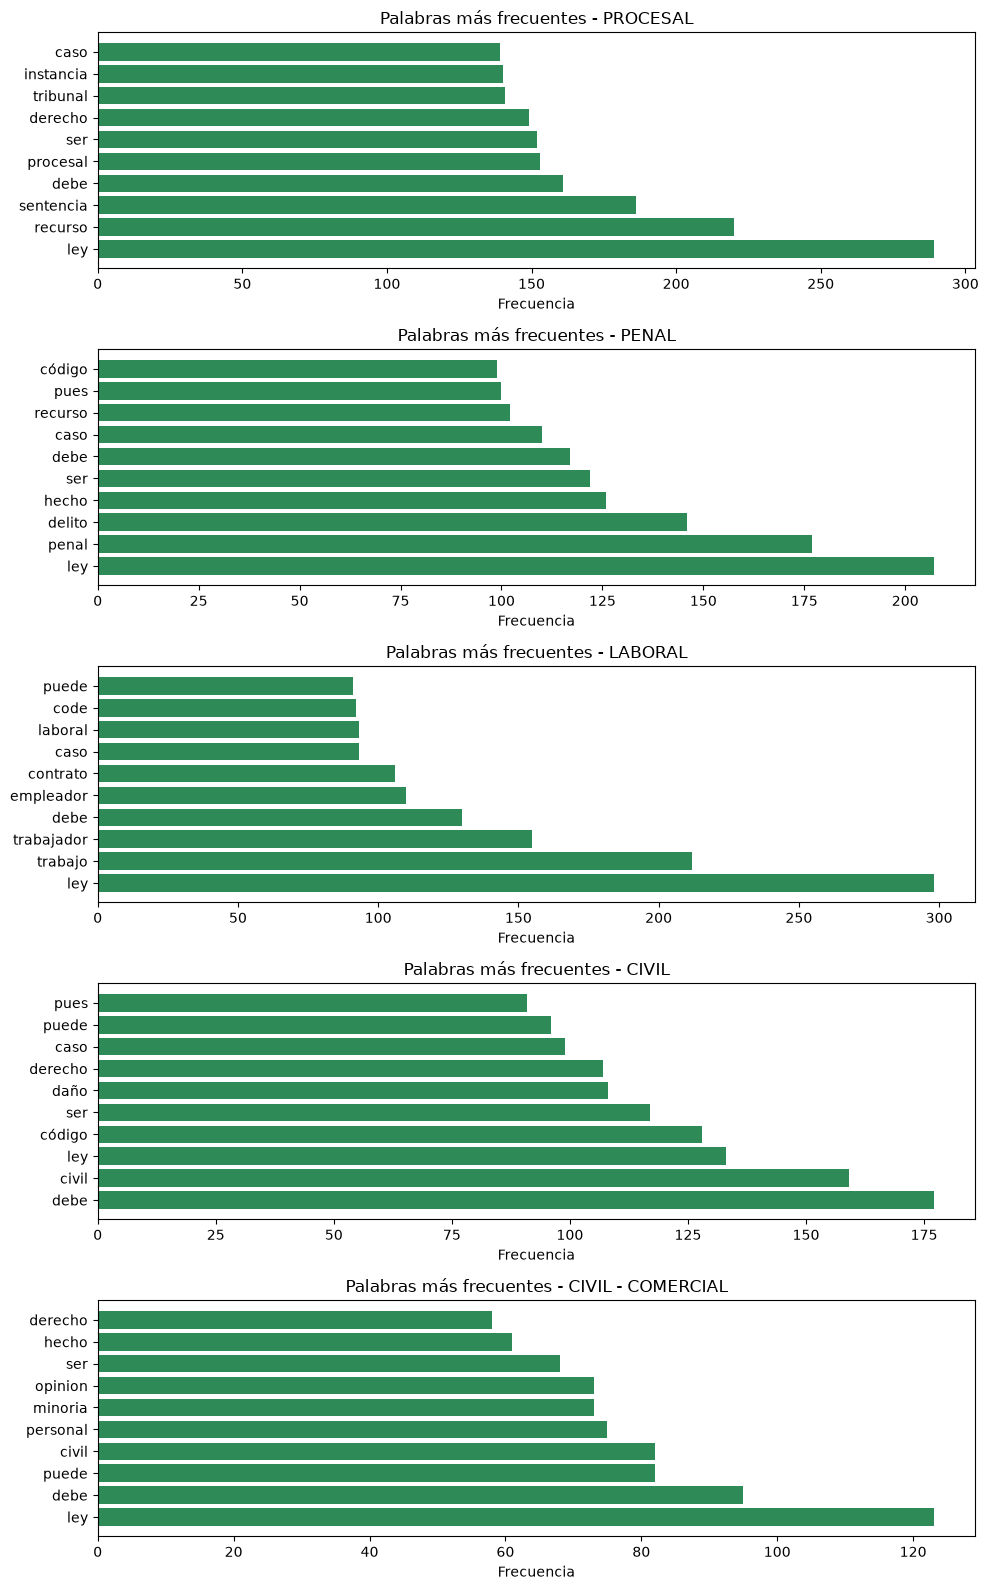

In [90]:
import matplotlib.pyplot as plt
from collections import Counter

if "materia" in df_sample_limpio.columns and "texto" in df_sample_limpio.columns:
    df_texto = df_sample_limpio[["materia", "texto"]].copy()
    df_texto["materia"] = (
        df_texto["materia"]
        .astype(str)
        .str.strip()
        .replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    )
    df_texto = df_texto.dropna(subset=["materia", "texto"])

    top_materias = (
        df_texto["materia"]
        .value_counts()
        .head(5)
        .index.tolist()
    )

    if top_materias:
        fig, axes = plt.subplots(len(top_materias), 1, figsize=(10, 3.2 * len(top_materias)))
        axes = axes.flatten()

        for ax, materia in zip(axes, top_materias):
            subset = df_texto[df_texto["materia"] == materia]
            tokens = [tok for texto in subset["texto"] for tok in tokenizar_y_limpiar(texto)]
            counter = Counter(tokens)
            top_words = counter.most_common(10)

            labels = [w for w, _ in top_words]
            values = [c for _, c in top_words]

            ax.barh(labels[::-1], values[::-1], color="seagreen")
            ax.set_title(f"Palabras más frecuentes - {materia}")
            ax.set_xlabel("Frecuencia")
            ax.invert_yaxis()

        plt.tight_layout()
        plt.show()
    else:
        print("No hay materias suficientes para graficar.")
else:
    print("No se encontraron las columnas 'materia' o 'texto'.")


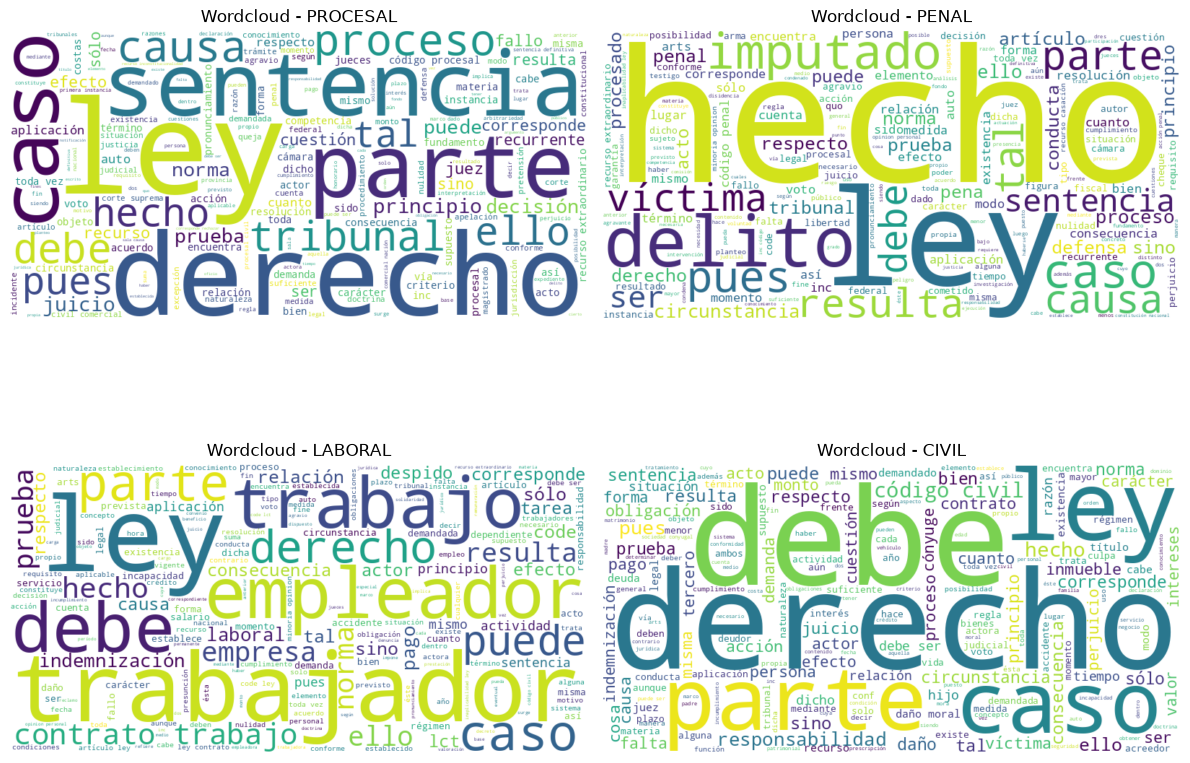

In [91]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

if "materia" in df_sample_limpio.columns and "texto" in df_sample_limpio.columns:
    df_wc = df_sample_limpio[["materia", "texto"]].copy()
    df_wc["materia"] = (
        df_wc["materia"]
        .astype(str)
        .str.strip()
        .replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    )
    df_wc = df_wc.dropna(subset=["materia", "texto"])

    top_materias = df_wc["materia"].value_counts().head(4).index.tolist()

    if top_materias:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()

        for ax, materia in zip(axes, top_materias):
            subset = df_wc[df_wc["materia"] == materia]
            texto = " ".join(subset["texto"].astype(str).tolist())
            tokens = tokenizar_y_limpiar(texto)
            texto_limpio = " ".join(tokens)

            wc = WordCloud(
                width=800,
                height=400,
                background_color="white",
                colormap="viridis"
            ).generate(texto_limpio)

            ax.imshow(wc, interpolation="bilinear")
            ax.set_title(f"Wordcloud - {materia}")
            ax.axis("off")

        for ax in axes[len(top_materias):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("No hay materias suficientes para generar wordclouds.")
else:
    print("No se encontraron las columnas 'materia' o 'texto'.")


In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt

if "materia" in df_sample_limpio.columns and "texto" in df_sample_limpio.columns:
    df_tfidf = df_sample_limpio[["materia", "texto"]].copy()
    df_tfidf["materia"] = (
        df_tfidf["materia"]
        .astype(str)
        .str.strip()
        .replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    )
    df_tfidf = df_tfidf.dropna(subset=["materia", "texto"])

    top_materias = df_tfidf["materia"].value_counts().head(4).index.tolist()
    df_tfidf = df_tfidf[df_tfidf["materia"].isin(top_materias)]

    if not df_tfidf.empty:
        docs = []
        labels = []
        for materia in top_materias:
            subset = df_tfidf[df_tfidf["materia"] == materia]
            textos = subset["texto"].astype(str).tolist()
            docs.extend(textos)
            labels.extend([materia] * len(textos))

        vectorizer = TfidfVectorizer(
            stop_words=stop_words,
            ngram_range=(1, 2),
            max_features=100
        )
        X = vectorizer.fit_transform(docs)

        feature_names = vectorizer.get_feature_names_out()
        feature_scores = X.toarray()

        # Promedio por clase para resaltar términos distintivos
        scores_by_label = {}
        for materia in top_materias:
            idx = [i for i, label in enumerate(labels) if label == materia]
            if idx:
                scores_by_label[materia] = feature_scores[idx].mean(axis=0)
            else:
                scores_by_label[materia] = np.zeros(X.shape[1])

        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()

        for ax, materia in zip(axes, top_materias):
            scores = scores_by_label[materia]
            top_idx = np.argsort(scores)[-8:][::-1]
            top_terms = [(feature_names[i], scores[i]) for i in top_idx]

            terms = [t for t, _ in top_terms]
            vals = [v for _, v in top_terms]

            ax.barh(terms[::-1], vals[::-1], color="tomato")
            ax.set_title(f"TF-IDF top terms - {materia}")
            ax.set_xlabel("Score TF-IDF")
            ax.invert_yaxis()

        for ax in axes[len(top_materias):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos suficientes para TF-IDF.")
else:
    print("No se encontraron las columnas 'materia' o 'texto'.")


InvalidParameterError: The 'stop_words' parameter of TfidfVectorizer must be a str among {'english'}, an instance of 'list' or None. Got {'estadas', 'estuve', 'habrían', 'con', 'hemos', 'has', 'habrías', 'estarías', 'nuestra', 'sois', 'habrás', 'donde', 'hubiese', 'contra', 'estar', 'habéis', 'hayáis', 'sea', 'seríamos', 'tuvimos', 'suyos', 'durante', 'estuvieseis', 'estaríamos', 'habremos', 'porque', 'tendrán', 'sin', 'estaréis', 'tenidas', 'tanto', 'estuviesen', 'tendrás', 'habidos', 'algunos', 'tuvieses', 'ya', 'tenían', 'estáis', 'estando', 'tuyo', 'hubimos', 'estés', 'hubieron', 'habían', 'teniendo', 'os', 'fuera', 'uuid', 'en', 'estaremos', 'sentida', 'estaría', 'mucho', 'tengáis', 'hayas', 'teníais', 'este', 'habidas', 'estás', 'tuve', 'como', 'una', 'fue', 'cuando', 'unos', 'hubieseis', 'habría', 'te', 'hubiera', 'quienes', 'serás', 'vuestro', 'un', 'mi', 'la', 'habías', 'soy', 'fueron', 'tuviesen', 'tendréis', 'hubieran', 'estarán', 'ante', 'hay', 'vuestras', 'mí', 'mis', 'ten

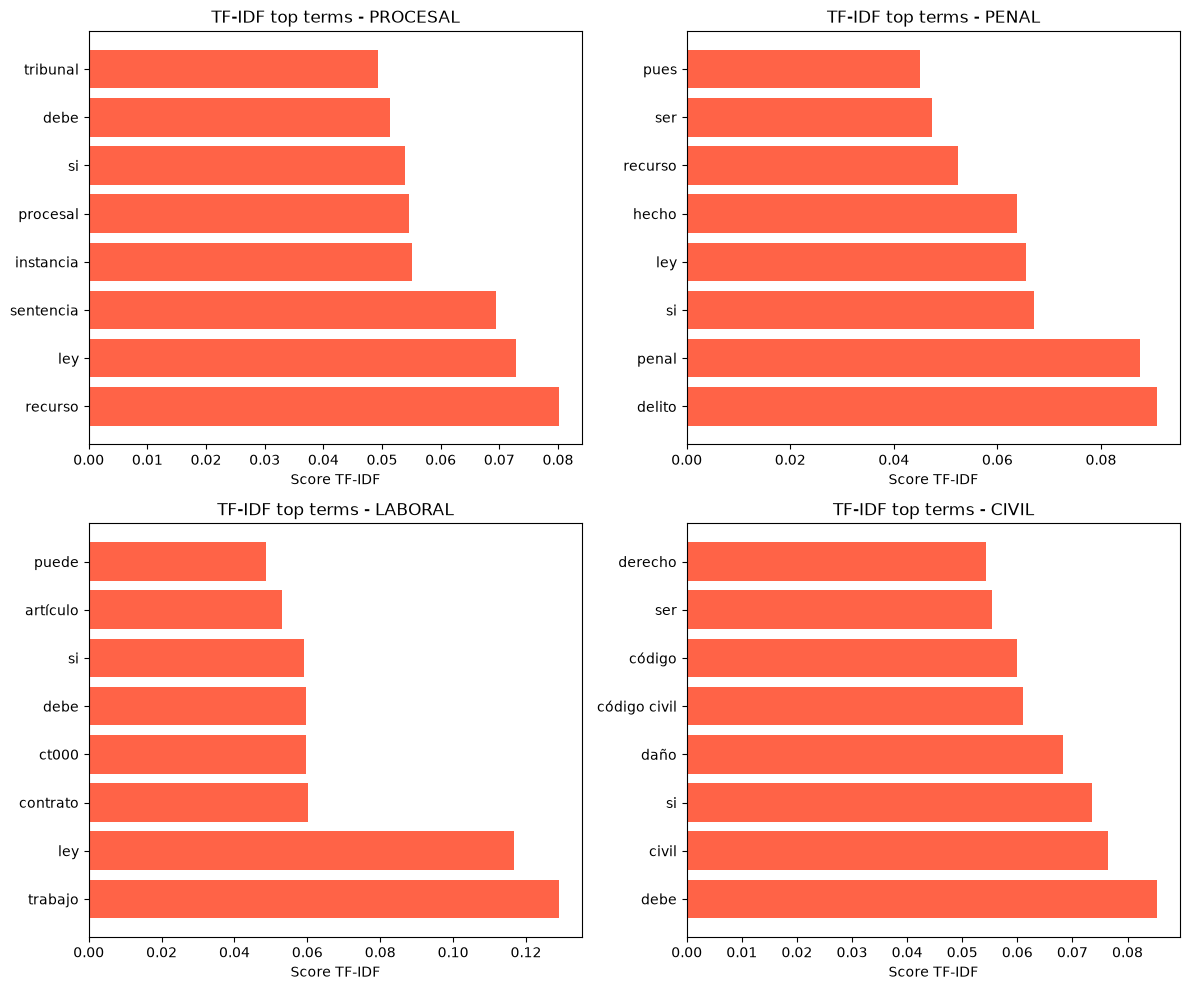

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt

if "materia" in df_sample_limpio.columns and "texto" in df_sample_limpio.columns:
    df_tfidf = df_sample_limpio[["materia", "texto"]].copy()
    df_tfidf["materia"] = (
        df_tfidf["materia"]
        .astype(str)
        .str.strip()
        .replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    )
    df_tfidf = df_tfidf.dropna(subset=["materia", "texto"])

    top_materias = df_tfidf["materia"].value_counts().head(10).index.tolist()
    df_tfidf = df_tfidf[df_tfidf["materia"].isin(top_materias)]

    if not df_tfidf.empty:
        docs = []
        labels = []
        for materia in top_materias:
            subset = df_tfidf[df_tfidf["materia"] == materia]
            textos = subset["texto"].astype(str).tolist()
            docs.extend(textos)
            labels.extend([materia] * len(textos))

        stop_words_list = list(stop_words)
        vectorizer = TfidfVectorizer(
            stop_words=stop_words_list,
            ngram_range=(1, 2),
            max_features=100
        )
        X = vectorizer.fit_transform(docs)

        feature_names = vectorizer.get_feature_names_out()
        feature_scores = X.toarray()

        scores_by_label = {}
        for materia in top_materias:
            idx = [i for i, label in enumerate(labels) if label == materia]
            if idx:
                scores_by_label[materia] = feature_scores[idx].mean(axis=0)
            else:
                scores_by_label[materia] = np.zeros(X.shape[1])

        fig, axes = plt.subplots(4, 4, figsize=(12, 10))
        axes = axes.flatten()

        for ax, materia in zip(axes, top_materias):
            scores = scores_by_label[materia]
            top_idx = np.argsort(scores)[-8:][::-1]
            top_terms = [(feature_names[i], scores[i]) for i in top_idx]

            terms = [t for t, _ in top_terms]
            vals = [v for _, v in top_terms]

            ax.barh(terms[::-1], vals[::-1], color="tomato")
            ax.set_title(f"TF-IDF top terms - {materia}")
            ax.set_xlabel("Score TF-IDF")
            ax.invert_yaxis()

        for ax in axes[len(top_materias):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos suficientes para TF-IDF.")
else:
    print("No se encontraron las columnas 'materia' o 'texto'.")


In [ ]:
for col in df_sample_limpio.columns:
    print(col)